##  Importation des Bibliothèques nécessaires

In [42]:
import pandas as pd, seaborn as sns, matplotlib.pyplot as plt, missingno as msno, plotly.express as px

##  Importation des Données

In [43]:
data = pd.read_csv("Dataset.csv")

## Copie De la base initiale

In [44]:
df = data.copy()

In [45]:
# structure du dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   ProductId             2000 non-null   object 
 1   ProductCategory       2000 non-null   object 
 2   ChannelId             2000 non-null   object 
 3   Amount                2000 non-null   float64
 4   Value                 2000 non-null   int64  
 5   TransactionStartTime  2000 non-null   object 
 6   PricingStrategy       2000 non-null   int64  
 7   FraudResult           2000 non-null   int64  
dtypes: float64(1), int64(3), object(4)
memory usage: 125.1+ KB


## Transformer la colonne $TransactionStartTime$ en datetime

In [46]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"],)
# voir les premières lignes
df.head()
# dimensions
df.shape

(2000, 8)

In [47]:

# statistiques descriptives
df.describe()

# noms des colonnes
#df.columns

,Amount,Value,PricingStrategy,FraudResult
count,2000.000000,2000.00000,2000.000000,2000.000000
mean,5913.507545,7154.24850,2.164500,0.003000
std,45054.442262,44938.27784,0.673548,0.054704
min,-60000.000000,8.00000,0.000000,0.000000
25%,-50.000000,100.00000,2.000000,0.000000
50%,900.000000,1000.00000,2.000000,0.000000
75%,2000.000000,3500.00000,2.000000,0.000000
max,800000.000000,800000.00000,4.000000,1.000000


### Visualiser le taux des valeurs manquantes pour chaque variable

In [48]:
df.isnull().sum()/df.shape[0]

ProductId               0.0
ProductCategory         0.0
ChannelId               0.0
Amount                  0.0
Value                   0.0
TransactionStartTime    0.0
PricingStrategy         0.0
FraudResult             0.0
dtype: float64

### Création de nouvelles variables

In [49]:
df["year"] = df["TransactionStartTime"].dt.year
df["month"] = df["TransactionStartTime"].dt.month_name()
df["day"] = df["TransactionStartTime"].dt.day_name()
df["hour"] = df["TransactionStartTime"].dt.hour

>   Connaitre la proportion (le nombre de fraude enregistré)

In [50]:
df[df['FraudResult'] == 1]
pd.DataFrame(df['FraudResult'].value_counts())

,count
FraudResult,
0,1994
1,6


## Les Différents Jours Ou Il y a eu Fraude

> Anlyse visuelle

In [51]:
jour_fraud = df.groupby("day")['FraudResult'].sum().reset_index()
px.bar(jour_fraud, x= "day", y = 'FraudResult', color= 'day')

In [52]:
heure_fraud = df.groupby("hour")['FraudResult'].sum().reset_index()
px.bar(heure_fraud, x= "hour", y = 'FraudResult', color= 'hour')

## Ensemble de transaction où il ya eu fraud

In [53]:
df_fraud = df[df.day.isin(["Saturday", "Thursday", "Tuesday"]) & (df["FraudResult"] == 1)]
canal_fraud = df_fraud.groupby(["day","ProductCategory", "ChannelId", 'hour'])['FraudResult'].sum().reset_index()
# Canal où il y a eu plus de fraud est le "financial_services"
#df_fraud.describe()
canal_fraud

,day,ProductCategory,ChannelId,hour,FraudResult
0,Saturday,financial_services,ChannelId_3,11,1
1,Thursday,financial_services,ChannelId_1,8,1
2,Thursday,financial_services,ChannelId_3,8,2
3,Tuesday,financial_services,ChannelId_3,12,2


## Distribution des montants

Text(0.5, 1.0, 'Distribution des montants')

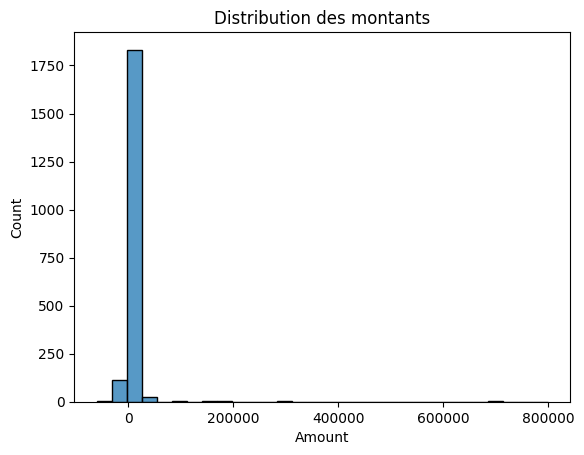

In [54]:
sns.histplot(df["Amount"], bins=30)
plt.title("Distribution des montants")

## Fraude par canal de transaction

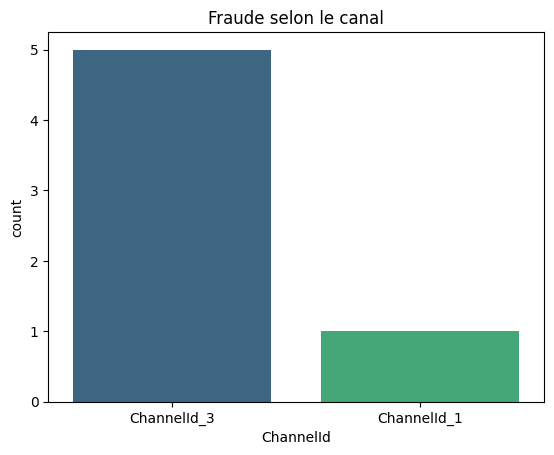

In [55]:
sns.countplot(x="ChannelId", hue="ChannelId", data=df_fraud, palette="viridis")
plt.title("Fraude selon le canal")
plt.show()

## Fraude selon la catégorie du produit

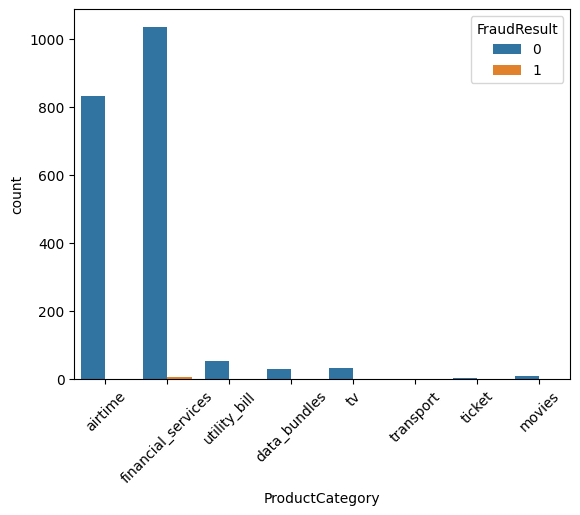

In [56]:
sns.countplot(x="ProductCategory", hue="FraudResult", data=df)
plt.xticks(rotation=45)
plt.show()

##  Corrélations

<Axes: >

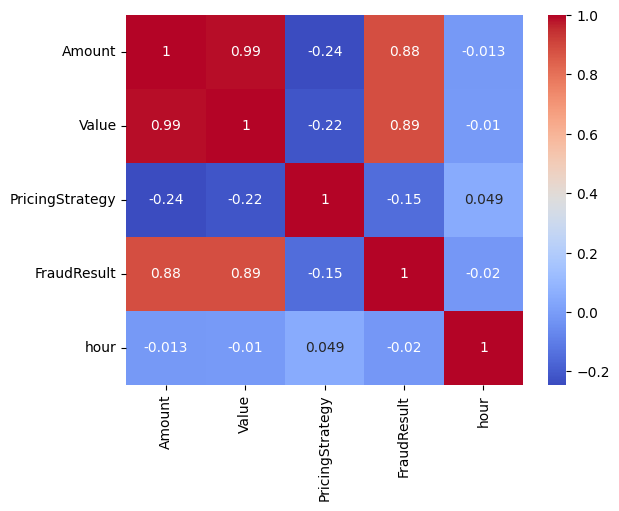

In [57]:
corr = df.drop("year", axis = 1).corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm")

## Scatter plot interactif

In [58]:
fig = px.scatter(df, x="Amount", y="Value", color="FraudResult", title="Relation entre Amount et Value")
fig.show()

##  Fraude par catégorie de produit

In [59]:
fig = px.histogram(
    df,
    x="ProductCategory",
    color="FraudResult",
    title="Fraude par catégorie de produit",
    barmode='group')

##  Transactions par heure

In [60]:
fig = px.histogram(df, x="hour", title="Distribution des transactions par heure")
fig.show()

In [ ]:
df.to_csv("Dataclaeaned.csv", index=False)
df_fraud.to_csv("DataFraud.csv", index=False)
